In [3]:
import pandas as pd

df = pd.read_csv("HealthcareDataset_Clean.csv", sep=";")

In [4]:
print(df.head())

            Name  Age  Gender Blood_Type Medical_Condition Date_of_Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance_Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing_Amount  Room_Number Admission_Type Discharge_Date   Medication  \
0        18856.28    

In [5]:
df.shape

(54860, 15)

In [6]:
df["Name"] = df["Name"].str.title()

In [7]:
df.head()

,Name,Age,Gender,Blood_Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Emergency,2024-02-02,Paracetamol,Normal\r
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive\r
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal\r
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal\r
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Emergency,2022-10-09,Penicillin,Abnormal\r


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54860 entries, 0 to 54859
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54860 non-null  object 
 1   Age                 54860 non-null  int64  
 2   Gender              54860 non-null  object 
 3   Blood_Type          54860 non-null  object 
 4   Medical_Condition   54860 non-null  object 
 5   Date_of_Admission   54860 non-null  object 
 6   Doctor              54860 non-null  object 
 7   Hospital            54860 non-null  object 
 8   Insurance_Provider  54860 non-null  object 
 9   Billing_Amount      54860 non-null  float64
 10  Room_Number         54860 non-null  int64  
 11  Admission_Type      54860 non-null  object 
 12  Discharge_Date      54860 non-null  object 
 13  Medication          54860 non-null  object 
 14  Test_Results        54860 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.3

In [9]:
df.describe()

,Age,Billing_Amount,Room_Number
count,54860.000000,54860.000000,54860.000000
mean,51.533850,25594.633612,301.109752
std,19.605295,14175.867046,115.217195
min,13.000000,9.240000,101.000000
25%,35.000000,13299.750000,202.000000
50%,52.000000,25593.875000,302.000000
75%,68.000000,37847.065000,400.000000
max,89.000000,52764.280000,500.000000


In [11]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood_Type            0
Medical_Condition     0
Date_of_Admission     0
Doctor                0
Hospital              0
Insurance_Provider    0
Billing_Amount        0
Room_Number           0
Admission_Type        0
Discharge_Date        0
Medication            0
Test_Results          0
dtype: int64

In [12]:
df["Date_of_Admission"] = pd.to_datetime(df["Date_of_Admission"])
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"])
df["Stay_Days"] = (df["Discharge_Date"] - df["Date_of_Admission"]).dt.days

In [13]:
df.head()

,Name,Age,Gender,Blood_Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results,Stay_Days
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28,328,Emergency,2024-02-02,Paracetamol,Normal\r,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.33,265,Emergency,2019-08-26,Ibuprofen,Inconclusive\r,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.10,205,Emergency,2022-10-07,Aspirin,Normal\r,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,2020-12-18,Ibuprofen,Abnormal\r,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.32,458,Emergency,2022-10-09,Penicillin,Abnormal\r,20


In [14]:
df["Gender"].value_counts()

Gender
Male      27449
Female    27411
Name: count, dtype: int64

In [16]:
df["Age"].describe()

count    54860.000000
mean        51.533850
std         19.605295
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

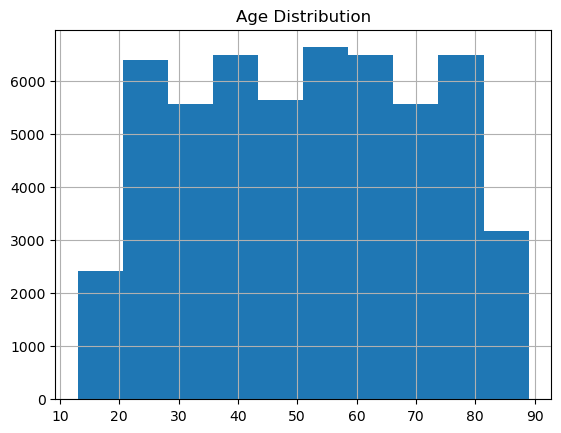

In [17]:
import matplotlib.pyplot as plt
df["Age"].hist()
plt.title("Age Distribution")
plt.show()

In [19]:
df["Medical_Condition"].value_counts()

Medical_Condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64

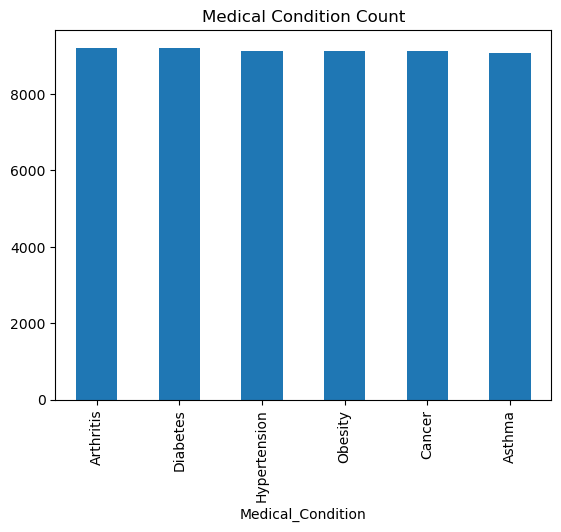

In [21]:
df["Medical_Condition"].value_counts().plot(kind="bar")
plt.title("Medical Condition Count")
plt.show()

In [22]:
df["Admission_Type"].value_counts()

Admission_Type
Emergency    36423
Elective     18437
Name: count, dtype: int64

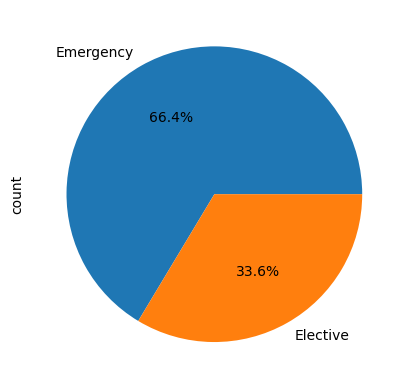

In [24]:
df["Admission_Type"].value_counts().plot(kind='pie',autopct="%1.1f%%")
plt.show()

In [25]:
df["Billing_Amount"].mean()

np.float64(25594.63361228582)

In [26]:
df.nlargest(10,"Billing_Amount")

,Name,Age,Gender,Blood_Type,Medical_Condition,Date_of_Admission,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test_Results,Stay_Days
36293,Todd Carrillo,51,Female,A+,Hypertension,2023-09-08,Kathleen Griffin,Griffin Group,Blue Cross,52764.28,209,Elective,2023-10-04,Ibuprofen,Normal\r,26
34559,Karen Kline,79,Female,AB+,Cancer,2021-06-19,Dr. Joseph Gordon,Hernandez-Morton,UnitedHealthcare,52373.03,181,Emergency,2021-07-03,Penicillin,Inconclusive\r,14
51083,Karen Kline,74,Female,AB+,Cancer,2021-06-19,Dr. Joseph Gordon,Hernandez-Morton,UnitedHealthcare,52373.03,181,Emergency,2021-07-03,Penicillin,Inconclusive\r,14
5725,David Sandoval,22,Male,AB-,Hypertension,2019-11-02,Taylor Novak,Sons and Bailey,Blue Cross,52271.66,228,Emergency,2019-11-11,Ibuprofen,Normal\r,9
7074,Kathryn Gonzales,18,Female,O+,Diabetes,2020-08-11,Kristin Clark,Miller Ltd,Aetna,52211.85,383,Emergency,2020-08-12,Paracetamol,Inconclusive\r,1
1570,Brett Marshall,42,Female,B+,Asthma,2021-11-10,Robert Hartman,PLC Garner,Aetna,52181.84,140,Emergency,2021-11-17,Penicillin,Inconclusive\r,7
6651,Laurie Hood,42,Female,A-,Arthritis,2021-06-27,Brian Riley,Walker-Garcia,Cigna,52170.04,306,Emergency,2021-06-29,Penicillin,Normal\r,2
52448,Laurie Hood,43,Female,A-,Arthritis,2021-06-27,Brian Riley,Walker-Garcia,Cigna,52170.04,306,Emergency,2021-06-29,Penicillin,Normal\r,2
33069,Justin Clark,53,Female,AB+,Cancer,2019-05-30,Andrea Jones,Ruiz-Anthony,UnitedHealthcare,52154.24,399,Emergency,2019-06-22,Aspirin,Normal\r,23
34314,Scott Powell,38,Female,B+,Cancer,2019-05-20,Stephen Hood PhD,George-Gonzalez,Cigna,52102.24,155,Emergency,2019-05-29,Ibuprofen,Normal\r,9


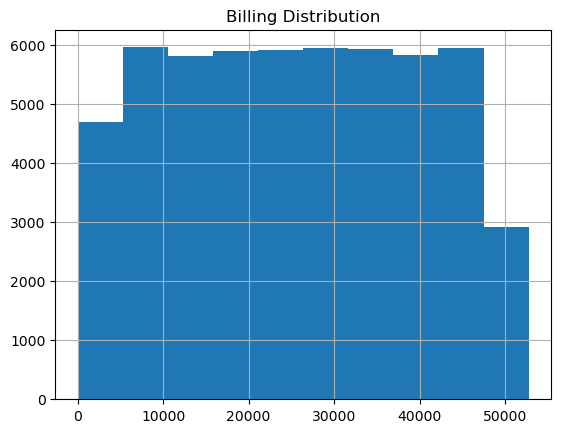

In [29]:
df["Billing_Amount"].hist()
plt.title("Billing Distribution")
plt.show()

In [30]:
df["Hospital"].value_counts()

Hospital
LLC Smith                        44
Ltd Smith                        39
Johnson PLC                      37
Smith Ltd                        37
Smith PLC                        36
                                 ..
Buchanan Wheeler and Roberts,     1
LLC Conner                        1
Guzman Jones and Graves,          1
and Williams, Brown Mckenzie      1
and Garcia Morris Cunningham,     1
Name: count, Length: 39815, dtype: int64

In [32]:
df.groupby("Hospital")["Billing_Amount"].sum().sort_values(ascending=False)

Hospital
Johnson PLC                  1081477.32
LLC Smith                    1030189.88
Smith PLC                    1029424.47
Ltd Smith                    1003365.53
Smith Ltd                     970035.87
                                ...    
Rowe, Stone and Patterson         49.45
Wilcox, Parker and White          46.80
Allen-Allen                       32.63
Hebert-Wells                      23.73
Perez Hoover, Moore and            9.24
Name: Billing_Amount, Length: 39815, dtype: float64

In [33]:
df["Insurance_Provider"].value_counts()

Insurance_Provider
Cigna               11115
Medicare            11018
UnitedHealthcare    10995
Blue Cross          10937
Aetna               10795
Name: count, dtype: int64

In [34]:
df.groupby("Insurance_Provider")["Billing_Amount"].sum()

Insurance_Provider
Aetna               2.765167e+08
Blue Cross          2.804167e+08
Cigna               2.843465e+08
Medicare            2.829212e+08
UnitedHealthcare    2.799205e+08
Name: Billing_Amount, dtype: float64

In [35]:
df["Stay_Days"].mean()

np.float64(15.498815165876778)

In [36]:
df.groupby("Medical_Condition")["Stay_Days"].mean()

Medical_Condition
Arthritis       15.503747
Asthma          15.676104
Cancer          15.510141
Diabetes        15.429488
Hypertension    15.435440
Obesity         15.439465
Name: Stay_Days, dtype: float64

In [37]:
df.corr(numeric_only=True)

,Age,Billing_Amount,Room_Number,Stay_Days
Age,1.000000,-0.003309,-0.000305,0.008022
Billing_Amount,-0.003309,1.000000,-0.003716,-0.004801
Room_Number,-0.000305,-0.003716,1.000000,-0.004563
Stay_Days,0.008022,-0.004801,-0.004563,1.000000


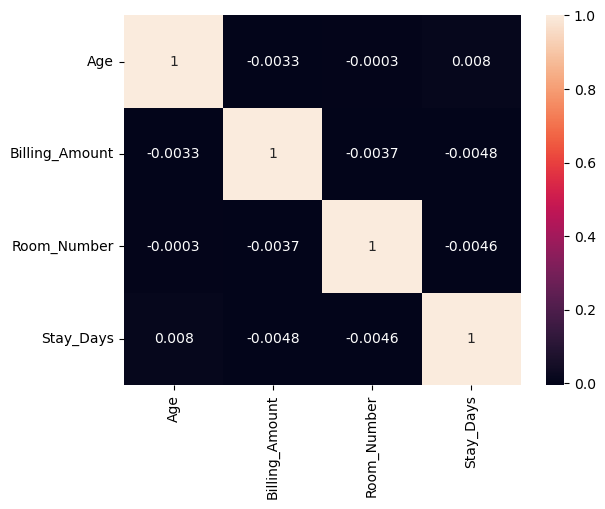

In [38]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [39]:
df.to_csv("healthcare_final.csv",index=False)